## Импорт библиотек, загрузка датасетов

In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)   # показывать все колонки
pd.set_option('display.max_colwidth', None)  # не обрезать содержимое ячеек (по необходимости)

test = pd.read_csv('data/test.csv')
train = pd.read_csv('data/train.csv')

## Просмотр дата сетов

In [103]:
print(test.shape)
print(test.info())
test.head(2)

(1784, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1784 entries, 0 to 1783
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1784 non-null   int64  
 1   main                            1784 non-null   object 
 2   address                         1784 non-null   object 
 3   added                           1784 non-null   object 
 4   upped                           1685 non-null   object 
 5   view_count                      1784 non-null   int64  
 6   hearts                          1145 non-null   float64
 7   lat                             1784 non-null   float64
 8   lon                             1784 non-null   float64
 9   Тип предложения                 1784 non-null   object 
 10  Серия                           1784 non-null   object 
 11  Дом                             1784 non-null   object 
 12  Этаж                   

,id,main,address,added,upped,view_count,hearts,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,Газ,Санузел,Балкон,Входная дверь,Парковка,Высота потолков,Безопасность,Правоустанавливающие документы,Телефон,Интернет,Мебель,Возможность рассрочки,Возможность обмена,Разное,Пол,Возможность ипотеки,Площадь участка,Канализация,Питьевая вода,Электричество
0,1,"1-комн. кв., 46.5 м2","Бишкек, с. Кок-Джар, Конур Осмон, 6",Добавлено 19 дней назад,Поднято 9 часов назад,112,NaN,42.8124,74.6493,от агента,индивид. планировка,"кирпичный, 2024 г.",11 этаж из 12,"46.5 м2, жилая: 14.8 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,есть,NaN,NaN,NaN,NaN
1,2,"2-комн. кв., 48 м2","Бишкек, 12 м-н, 12 мкр-н",Добавлено 13 дней назад,Поднято 9 часов назад,176,1.0,42.8113,74.6371,от агента,элитка,"монолитный, 2020 г.",9 этаж из 10,48 м2,автономное,евроремонт,магистральный,совмещенный,балкон,бронированная,паркинг,3 м.,"домофон, охрана, кодовый замок, видеонаблюдение","технический паспорт, договор купли-продажи, красная книга",есть,проводной,пустая,NaN,NaN,"кухня-студия, пластиковые окна, неугловая, тихий двор",паркет,есть,NaN,NaN,NaN,NaN


In [104]:
print(train.shape)
print(train.info())
train.head(2)

(7134, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7134 entries, 0 to 7133
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   main                            7134 non-null   object 
 1   address                         7134 non-null   object 
 2   added                           7134 non-null   object 
 3   upped                           6700 non-null   object 
 4   view_count                      7134 non-null   int64  
 5   hearts                          4522 non-null   float64
 6   lat                             7134 non-null   float64
 7   lon                             7134 non-null   float64
 8   Тип предложения                 7134 non-null   object 
 9   Серия                           7133 non-null   object 
 10  Дом                             7134 non-null   object 
 11  Этаж                            7130 non-null   object 
 12  Площадь                

,main,address,added,upped,view_count,hearts,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,Газ,Санузел,Балкон,Входная дверь,Парковка,Высота потолков,Безопасность,Правоустанавливающие документы,Телефон,Интернет,Мебель,Возможность рассрочки,Возможность обмена,Разное,Пол,Возможность ипотеки,Площадь участка,Канализация,Питьевая вода,Электричество,usd_price
0,"3-комн. кв., 113.8 м2","Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,1.0,42.8711,74.5823,от агента,индивид. планировка,"кирпичный, 2017 г.",10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,3 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,есть,NaN,NaN,NaN,NaN,157000
1,"2-комн. кв., 66 м2","Бишкек, с. Кок-Джар, с.Кок-Жар, ул.Конкур Осмона 6/1",Добавлено 7 дней назад,Поднято 7 часов назад,102,NaN,42.8131,74.6482,от агента,элитка,"монолитный, 2023 г.",10 этаж из 12,66 м2,на газе,евроремонт,магистральный,совмещенный,нет,бронированная,паркинг,3 м.,"охрана, видеодомофон, видеонаблюдение, кодовый замок",NaN,NaN,NaN,частично меблирована,NaN,NaN,"пластиковые окна, неугловая, кладовка, тихий двор",ламинат,NaN,NaN,NaN,NaN,NaN,96500


## Подготовка датасетов

In [105]:
df = train.copy()
df_test = test.copy()
test_ids = test['id']

### main

In [106]:
s = df['main'].astype(str)

# rooms: первое число перед "комн"
df['rooms'] = s.str.extract(r'(\d+)(?:\s*(?:и\s*более|\+))?\s*[-–—]?\s*комн', expand=False)
df['rooms'] = pd.to_numeric(df['rooms'], errors='coerce').astype('Int64')  # nullable int

# square: число (с запятой или точкой) перед 'м' или 'm'
df['area'] = s.str.extract(r'([\d]+[.,]?\d*)\s*(?:м|m)', expand=False)
df['area'] = df['area'].str.replace(',', '.', regex=False).astype(float)

display(df[['main', 'rooms', 'area']].head())

# test
s_test = df_test['main'].astype(str)

# rooms: первое число перед "комн"
df_test['rooms'] = s_test.str.extract(r'(\d+)(?:\s*(?:и\s*более|\+))?\s*[-–—]?\s*комн', expand=False)
df_test['rooms'] = pd.to_numeric(df_test['rooms'], errors='coerce').astype('Int64')  # nullable int

# square: число (с запятой или точкой) перед 'м' или 'm'
df_test['area'] = s_test.str.extract(r'([\d]+[.,]?\d*)\s*(?:м|m)', expand=False)
df_test['area'] = df_test['area'].str.replace(',', '.', regex=False).astype(float)

display(df_test[['main', 'rooms', 'area']].head())

,main,rooms,area
0,"3-комн. кв., 113.8 м2",3,113.8
1,"2-комн. кв., 66 м2",2,66.0
2,"3-комн. кв., 68 м2",3,68.0
3,"4-комн. кв., 135 м2",4,135.0
4,"2-комн. кв., 67 м2",2,67.0


,main,rooms,area
0,"1-комн. кв., 46.5 м2",1,46.50
1,"2-комн. кв., 48 м2",2,48.00
2,"3-комн. кв., 88 м2",3,88.00
3,"4-комн. кв., 81.69 м2",4,81.69
4,"3-комн. кв., 119 м2",3,119.00


In [107]:
median_rooms = df['rooms'].median()
# train
df['rooms'] = df['rooms'].fillna(median_rooms).astype('int64')
df = df.drop('main', axis=1)

# test
df_test['rooms'] = df_test['rooms'].fillna(median_rooms).astype('int64')
df_test = df_test.drop('main', axis=1)


### Тип предложения

In [108]:
df["От собственника"] = df['Тип предложения'].apply(lambda x: 1 if x == 'от собственника' else 0)
df = df.drop(['Тип предложения'], axis=1)
# test
df_test["От собственника"] = df_test['Тип предложения'].apply(lambda x: 1 if x == 'от собственника' else 0)
df_test = df_test.drop(['Тип предложения'], axis=1)

### Дом

In [109]:
import datetime

s = df['Дом'].astype(str).str.strip()

# сначала попробовать найти полноценный 4-значный год, затем fallback на варианты вида "0 г." или "2025 г."
year1 = s.str.extract(r'(\d{4})', expand=False)
year2 = s.str.extract(r'(\d{1,4})\s*г\.?', expand=False)  # поймает и "0 г."
year_raw = year1.fillna(year2)

year = pd.to_numeric(year_raw, errors='coerce')
current_year = datetime.datetime.now().year
# считать год валидным только в разумном диапазоне; "0" и прочие некорректные значения станут NaN
year = year.where(year.between(1000, current_year + 1))
df['year'] = year.astype('Int64')  # nullable int

# удалить годовую часть из строки, получить тип дома
df['house_type'] = s.str.replace(r',?\s*(?:\d{1,4}\s*г\.?|\d{4})\s*$', '', regex=True).str.strip()
df['house_type'] = df['house_type'].replace({'': pd.NA})

df = df.drop('Дом', axis=1)

# test
s_test = df_test['Дом'].astype(str).str.strip()

# сначала попробовать найти полноценный 4-значный год, затем fallback на варианты вида "0 г." или "2025 г."
year1 = s_test.str.extract(r'(\d{4})', expand=False)
year2 = s_test.str.extract(r'(\d{1,4})\s*г\.?', expand=False)  # поймает и "0 г."
year_raw = year1.fillna(year2)

year = pd.to_numeric(year_raw, errors='coerce')
current_year = datetime.datetime.now().year
# считать год валидным только в разумном диапазоне; "0" и прочие некорректные значения станут NaN
year = year.where(year.between(1000, current_year + 1))
df_test['year'] = year.astype('Int64')  # nullable int

# удалить годовую часть из строки, получить тип дома
df_test['house_type'] = s_test.str.replace(r',?\s*(?:\d{1,4}\s*г\.?|\d{4})\s*$', '', regex=True).str.strip()
df_test['house_type'] = df_test['house_type'].replace({'': pd.NA})

df_test = df_test.drop('Дом', axis=1)

In [110]:
# Заполнить пустые строки
# train
df['Серия'] = df['Серия'].fillna('unknown')

series_medians = (
    df.groupby('Серия')['year']
      .median()
      .round()
)
global_median = round(df['year'].median())

df['year'] = df['year'].fillna(
    df['Серия'].map(series_medians)
)
df['year'] = df['year'].fillna(global_median)

df['year'] = df['year'].astype('Int64')

# TEST
df_test['Серия'] = df_test['Серия'].fillna('unknown')

df_test['year'] = df_test['year'].fillna(
    df_test['Серия'].map(series_medians)
)

df_test['year'] = df_test['year'].fillna(global_median)

df_test['year'] = df_test['year'].astype('Int64')

### Серия (One hot encoding)

In [111]:
import category_encoders as ce

In [112]:
# Значения в признаке 'Серия'
df['Серия'].value_counts()

Серия
элитка                  4772
индивид. планировка      965
104 серия                352
105 серия                306
106 серия                249
106 серия улучшенная     130
хрущевка                 127
108 серия                 90
105 серия улучшенная      37
малосемейка               35
сталинка                  23
пентхаус                  20
104 серия улучшенная      18
107 серия                  9
unknown                    1
Name: count, dtype: int64

In [113]:
# train
df['Серия'] = df['Серия'].replace({
    '104 серия улучшенная': '104 серия',
    '105 серия улучшенная': '105 серия',
    '106 серия улучшенная': '106 серия'
})

# test
df_test['Серия'] = df_test['Серия'].replace({
    '104 серия улучшенная': '104 серия',
    '105 серия улучшенная': '105 серия',
    '106 серия улучшенная': '106 серия'
})

In [114]:
# train
series_encoder = ce.OneHotEncoder(cols=['Серия'], use_cat_names=True)
df = series_encoder.fit_transform(df)

# test
df_test = series_encoder.transform(df_test)
df.head(3)

,address,added,upped,view_count,hearts,lat,lon,Серия_индивид. планировка,Серия_элитка,Серия_106 серия,Серия_хрущевка,Серия_104 серия,Серия_108 серия,Серия_105 серия,Серия_пентхаус,Серия_малосемейка,Серия_сталинка,Серия_107 серия,Серия_unknown,Этаж,Площадь,Отопление,Состояние,Газ,Санузел,Балкон,Входная дверь,Парковка,Высота потолков,Безопасность,Правоустанавливающие документы,Телефон,Интернет,Мебель,Возможность рассрочки,Возможность обмена,Разное,Пол,Возможность ипотеки,Площадь участка,Канализация,Питьевая вода,Электричество,usd_price,rooms,area,От собственника,year,house_type
0,"Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,1.0,42.8711,74.5823,1,0,0,0,0,0,0,0,0,0,0,0,10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,3 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,есть,NaN,NaN,NaN,NaN,157000,3,113.8,0,2017,кирпичный
1,"Бишкек, с. Кок-Джар, с.Кок-Жар, ул.Конкур Осмона 6/1",Добавлено 7 дней назад,Поднято 7 часов назад,102,NaN,42.8131,74.6482,0,1,0,0,0,0,0,0,0,0,0,0,10 этаж из 12,66 м2,на газе,евроремонт,магистральный,совмещенный,нет,бронированная,паркинг,3 м.,"охрана, видеодомофон, видеонаблюдение, кодовый замок",NaN,NaN,NaN,частично меблирована,NaN,NaN,"пластиковые окна, неугловая, кладовка, тихий двор",ламинат,NaN,NaN,NaN,NaN,NaN,96500,2,66.0,0,2023,монолитный
2,"Бишкек, 12 м-н, 12-й микрорайон, 69",Добавлено 5 дней назад,Поднято 9 часов назад,104,NaN,42.8129,74.6390,0,0,1,0,0,0,0,0,0,0,0,0,7 этаж из 9,"68 м2, жилая: 40 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,нет,NaN,NaN,NaN,NaN,108500,3,68.0,0,1990,кирпичный


### house_type

In [115]:
# train
house_type_encoder = ce.OneHotEncoder(cols='house_type', use_cat_names=True)
df = house_type_encoder.fit_transform(df)

# test
df_test = house_type_encoder.transform(df_test)
df.head(3)

,address,added,upped,view_count,hearts,lat,lon,Серия_индивид. планировка,Серия_элитка,Серия_106 серия,Серия_хрущевка,Серия_104 серия,Серия_108 серия,Серия_105 серия,Серия_пентхаус,Серия_малосемейка,Серия_сталинка,Серия_107 серия,Серия_unknown,Этаж,Площадь,Отопление,Состояние,Газ,Санузел,Балкон,Входная дверь,Парковка,Высота потолков,Безопасность,Правоустанавливающие документы,Телефон,Интернет,Мебель,Возможность рассрочки,Возможность обмена,Разное,Пол,Возможность ипотеки,Площадь участка,Канализация,Питьевая вода,Электричество,usd_price,rooms,area,От собственника,year,house_type_кирпичный,house_type_монолитный,house_type_панельный
0,"Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,1.0,42.8711,74.5823,1,0,0,0,0,0,0,0,0,0,0,0,10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,3 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,есть,NaN,NaN,NaN,NaN,157000,3,113.8,0,2017,1,0,0
1,"Бишкек, с. Кок-Джар, с.Кок-Жар, ул.Конкур Осмона 6/1",Добавлено 7 дней назад,Поднято 7 часов назад,102,NaN,42.8131,74.6482,0,1,0,0,0,0,0,0,0,0,0,0,10 этаж из 12,66 м2,на газе,евроремонт,магистральный,совмещенный,нет,бронированная,паркинг,3 м.,"охрана, видеодомофон, видеонаблюдение, кодовый замок",NaN,NaN,NaN,частично меблирована,NaN,NaN,"пластиковые окна, неугловая, кладовка, тихий двор",ламинат,NaN,NaN,NaN,NaN,NaN,96500,2,66.0,0,2023,0,1,0
2,"Бишкек, 12 м-н, 12-й микрорайон, 69",Добавлено 5 дней назад,Поднято 9 часов назад,104,NaN,42.8129,74.6390,0,0,1,0,0,0,0,0,0,0,0,0,7 этаж из 9,"68 м2, жилая: 40 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,нет,NaN,NaN,NaN,NaN,108500,3,68.0,0,1990,1,0,0


### Этаж

In [116]:
import re

def parse_floor_total(x):
    if pd.isna(x) or x == '':
        return (None, None)
    if 'цоколь' in x or 'цок.' in x:
        floor = 0
    else:
        m = re.search(r'(\d+)', x)
        floor = int(m.group(1)) if m else None
    m2 = re.search(r'из\s*(\d+)', x)
    if not m2:
        m2 = re.search(r'[\/\u2215]\s*(\d+)', x)  # обработать "3/9" и похожие
    total = int(m2.group(1)) if m2 else None
    return (floor, total)

# train
s = df['Этаж'].astype(str).str.strip().str.lower()
parsed = s.apply(parse_floor_total)
df['floor'] = parsed.apply(lambda t: pd.NA if t[0] is None else t[0]).astype('Int64')
df['total_floors'] = parsed.apply(lambda t: pd.NA if t[1] is None else t[1]).astype('Int64')
df = df.drop('Этаж',  axis=1)

# test
s_test = df_test['Этаж'].astype(str).str.strip().str.lower()
parsed_test = s_test.apply(parse_floor_total)

df_test['floor'] = parsed_test.apply(lambda t: pd.NA if t[0] is None else t[0]).astype('Int64')
df_test['total_floors'] = parsed_test.apply(lambda t: pd.NA if t[1] is None else t[1]).astype('Int64')
df_test = df_test.drop('Этаж',  axis=1)

In [117]:
# медианы из TRAIN
floor_median = df['floor'].median()
total_floors_median = df['total_floors'].median()

# train
df['floor'] = df['floor'].fillna(floor_median)
df['total_floors'] = df['total_floors'].fillna(total_floors_median)

# test
df_test['floor'] = df_test['floor'].fillna(floor_median)
df_test['total_floors'] = df_test['total_floors'].fillna(total_floors_median)

### Состояние и Отопление

In [118]:
#test
df['Состояние'] = df['Состояние'].fillna('unknown')
df['Отопление'] = df['Отопление'].fillna('unknown')

# test
df_test['Состояние'] = df_test['Состояние'].fillna('unknown')
df_test['Отопление'] = df_test['Отопление'].fillna('unknown')

In [119]:
oh_encoder = ce.OneHotEncoder(cols=['Состояние','Отопление'] , use_cat_names=True)
df = oh_encoder.fit_transform(df)

# test
df_test = oh_encoder.transform(df_test)

df.head(3)

,address,added,upped,view_count,hearts,lat,lon,Серия_индивид. планировка,Серия_элитка,Серия_106 серия,Серия_хрущевка,Серия_104 серия,Серия_108 серия,Серия_105 серия,Серия_пентхаус,Серия_малосемейка,Серия_сталинка,Серия_107 серия,Серия_unknown,Площадь,Отопление_unknown,Отопление_на газе,Отопление_центральное,Отопление_автономное,Отопление_электрическое,Отопление_смешанное,Отопление_на твердом топливе,Отопление_без отопления,Состояние_unknown,Состояние_евроремонт,Состояние_под самоотделку (псо),Состояние_хорошее,Состояние_среднее,Состояние_не достроено,Газ,Санузел,Балкон,Входная дверь,Парковка,Высота потолков,Безопасность,Правоустанавливающие документы,Телефон,Интернет,Мебель,Возможность рассрочки,Возможность обмена,Разное,Пол,Возможность ипотеки,Площадь участка,Канализация,Питьевая вода,Электричество,usd_price,rooms,area,От собственника,year,house_type_кирпичный,house_type_монолитный,house_type_панельный,floor,total_floors
0,"Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,1.0,42.8711,74.5823,1,0,0,0,0,0,0,0,0,0,0,0,"113.8 м2, жилая: 62.9 м2",1,0,0,0,0,0,0,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,3 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,есть,NaN,NaN,NaN,NaN,157000,3,113.8,0,2017,1,0,0,10,12
1,"Бишкек, с. Кок-Джар, с.Кок-Жар, ул.Конкур Осмона 6/1",Добавлено 7 дней назад,Поднято 7 часов назад,102,NaN,42.8131,74.6482,0,1,0,0,0,0,0,0,0,0,0,0,66 м2,0,1,0,0,0,0,0,0,0,1,0,0,0,0,магистральный,совмещенный,нет,бронированная,паркинг,3 м.,"охрана, видеодомофон, видеонаблюдение, кодовый замок",NaN,NaN,NaN,частично меблирована,NaN,NaN,"пластиковые окна, неугловая, кладовка, тихий двор",ламинат,NaN,NaN,NaN,NaN,NaN,96500,2,66.0,0,2023,0,1,0,10,12
2,"Бишкек, 12 м-н, 12-й микрорайон, 69",Добавлено 5 дней назад,Поднято 9 часов назад,104,NaN,42.8129,74.6390,0,0,1,0,0,0,0,0,0,0,0,0,"68 м2, жилая: 40 м2",1,0,0,0,0,0,0,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,2.8 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,нет,NaN,NaN,NaN,NaN,108500,3,68.0,0,1990,1,0,0,7,9


### Правоустанавливающие документы

In [120]:
# train
df['red_book'] = df['Правоустанавливающие документы'].str.contains('красная книга', na=False).astype(int)
df['tech_passport'] = df['Правоустанавливающие документы'].str.contains('технический паспорт', na=False).astype(int)
df['sale_contract'] = df['Правоустанавливающие документы'].str.contains('договор купли-продажи', na=False).astype(int)
df.drop('Правоустанавливающие документы', axis=1, inplace=True)
    
# test
df_test['red_book'] = df_test['Правоустанавливающие документы'].str.contains('красная книга', na=False).astype(int)
df_test['tech_passport'] = df_test['Правоустанавливающие документы'].str.contains('технический паспорт', na=False).astype(int)
df_test['sale_contract'] = df_test['Правоустанавливающие документы'].str.contains('договор купли-продажи', na=False).astype(int)
df_test.drop('Правоустанавливающие документы', axis=1, inplace=True)

### usd_price

In [121]:
# train
df['price_per_sqm'] = df['usd_price'] / df['area']

## Отбор признаков

In [122]:
train_processed = df.select_dtypes(include='number')
test_processed = df_test.select_dtypes(include='number')

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7134 entries, 0 to 7133
Data columns (total 67 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   address                          7134 non-null   object 
 1   added                            7134 non-null   object 
 2   upped                            6700 non-null   object 
 3   view_count                       7134 non-null   int64  
 4   hearts                           4522 non-null   float64
 5   lat                              7134 non-null   float64
 6   lon                              7134 non-null   float64
 7   Серия_индивид. планировка        7134 non-null   int64  
 8   Серия_элитка                     7134 non-null   int64  
 9   Серия_106 серия                  7134 non-null   int64  
 10  Серия_хрущевка                   7134 non-null   int64  
 11  Серия_104 серия                  7134 non-null   int64  
 12  Серия_108 серия     

In [124]:
cols_to_drop = [
    'view_count',
    'hearts',
    'lat', 
    'lon',
    'Серия_unknown',
    'Отопление_unknown',
    'Состояние_unknown',
]
# train
train_processed = train_processed.drop(columns=cols_to_drop)
train_processed =  train_processed.drop('usd_price', axis=1)

# test
test_processed = test_processed.drop(columns=cols_to_drop)
test_processed = test_processed.drop(columns=['Канализация', 'Питьевая вода', 'Площадь участка', 'Электричество'])

### Проверка на мультиколлинеарность

Text(0.5, 1.0, 'Корреляция между числовыми признаками')

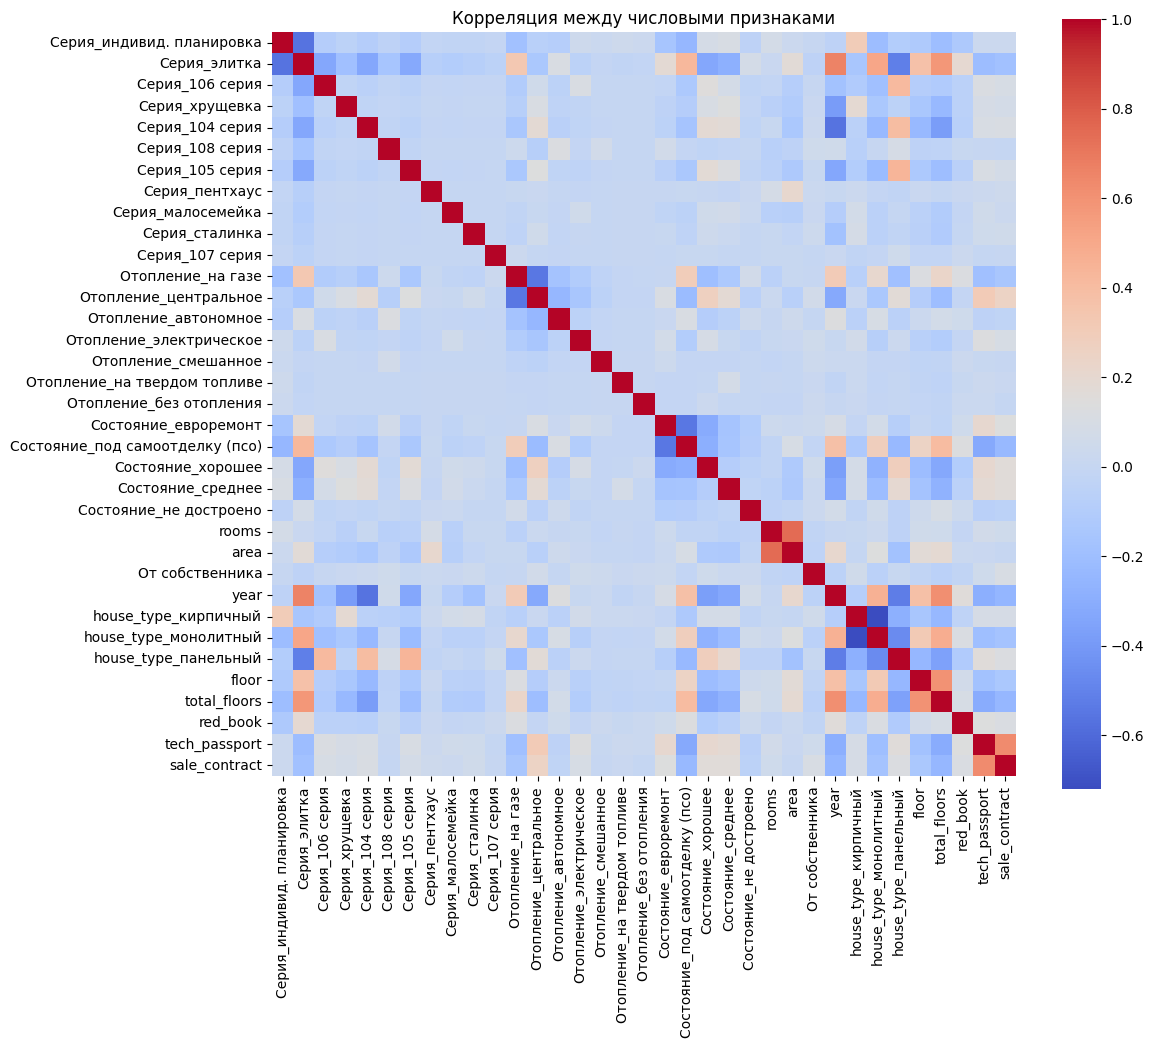

In [125]:
train_check = train_processed.drop(columns=['price_per_sqm'])
plt.figure(figsize=(12, 10))
sns.heatmap(train_check.corr(), annot=False, cmap='coolwarm', square=True)
plt.title('Корреляция между числовыми признаками')

In [126]:
corr_matrix = train_check.corr().abs()
hot_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.columns[i] != corr_matrix.columns[j] and corr_matrix.iloc[i, j] > 0.8:
            hot_corr.append({
                '1: ': corr_matrix.columns[i],
                '2: ': corr_matrix.columns[j],
                'Correlation: ': corr_matrix.iloc[i, j]
                })
hot_corr

[]

#### Вывод - сильной корреляции между признаками нет

## Сохранении подготовленных данных

In [127]:
train_processed.to_csv('data/train_preprocessed.csv', index=False)
test_processed.to_csv('data/test_preprocessed.csv', index=False)